# Plotting a Sequence of Nests for a Selected Segment

This creates an overview of variables simulated in the different nests.

Using levante python kernel "1 Python 3" (can be recreated from `../environment-standard.yml`)

In [1]:
#%matplotlib inline

import os, sys, glob
import pylab as plt
import numpy as np
import scipy.ndimage

#import seaborn as sns
#sns.set_context('paper')

import datetime
import xarray as xr
xr.set_options(keep_attrs=True)

import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import seaborn as sns
sns.set_context( 'talk' )

In [2]:
sys.path.append('../tools')
import timetools


## Arguments 

In [3]:
if 'launcher' in sys.argv[0]:
    time_str = '20200912_1800'
else:
    time_str = sys.argv[2]

time = datetime.datetime.strptime(time_str, '%Y%m%d_%H%M')


## Open ICON Data

### Time Coordinate

In [4]:
def reset_timecoord( dset ):
    t = timetools.convert_timevec( dset.time.data )
    return dset.assign_coords({'time':t})



### ICON LEM 

In [5]:

def input_LEM( dom, time, mode = 'surface'):

    data_path = f'/work/bb1376/data/icon/atlantic-cases/paulette//hurricane-centric_paulette2020-width100km_reinit12h-segment??-2020????T????Z-exp111/POSTPROC'
    
    
    date_string = time.strftime('%Y%m%d') # '20200910T0??000Z'

    print(f'{data_path}/2d_{mode}_{dom}*{date_string}*regrid?km.nc')
    icon_regrid_files =  sorted( glob.glob( f'{data_path}/2d_{mode}_{dom}*{date_string}*regrid?km.nc') )
  
    for fname in icon_regrid_files:
        irg = xr.open_dataset( fname, )
        irg = reset_timecoord( irg )

        try:
            irg = irg.sel(time=time)
            try:
                irg = irg.isel(time=0)
            except:
                pass
                
            return irg.expand_dims({'dom':[dom,]})
        except:
#            print('time not found')
            continue

    return xr.zeros_like( irg.isel(time = 0) )



In [6]:
surface1200 = input_LEM('DOM01',time,)
surface600 = input_LEM('DOM02',time,)
surface300 = input_LEM('DOM03',time,)

cloud1200 = input_LEM('DOM01',time, mode = 'cloud')
cloud600 = input_LEM('DOM02',time, mode = 'cloud')
cloud300 = input_LEM('DOM03',time, mode = 'cloud')

rad1200 = input_LEM('DOM01',time, mode = 'rad')
rad600 = input_LEM('DOM02',time, mode = 'rad')
rad300 = input_LEM('DOM03',time, mode = 'rad')

d1200 = xr.merge([surface1200, cloud1200, rad1200])
d600 = xr.merge([surface600, cloud600, rad600])
d300 = xr.merge([surface300, cloud300, rad300])



/work/bb1376/data/icon/atlantic-cases/paulette//hurricane-centric_paulette2020-width100km_reinit12h-segment??-2020????T????Z-exp111/POSTPROC/2d_surface_DOM01*20200912*regrid?km.nc
/work/bb1376/data/icon/atlantic-cases/paulette//hurricane-centric_paulette2020-width100km_reinit12h-segment??-2020????T????Z-exp111/POSTPROC/2d_surface_DOM02*20200912*regrid?km.nc
/work/bb1376/data/icon/atlantic-cases/paulette//hurricane-centric_paulette2020-width100km_reinit12h-segment??-2020????T????Z-exp111/POSTPROC/2d_surface_DOM03*20200912*regrid?km.nc
/work/bb1376/data/icon/atlantic-cases/paulette//hurricane-centric_paulette2020-width100km_reinit12h-segment??-2020????T????Z-exp111/POSTPROC/2d_cloud_DOM01*20200912*regrid?km.nc
/work/bb1376/data/icon/atlantic-cases/paulette//hurricane-centric_paulette2020-width100km_reinit12h-segment??-2020????T????Z-exp111/POSTPROC/2d_cloud_DOM02*20200912*regrid?km.nc
/work/bb1376/data/icon/atlantic-cases/paulette//hurricane-centric_paulette2020-width100km_reinit12h-segm

In [7]:
d1200 = d1200.where( d1200['t_2m'] > 0 )
d600 = d600.where( d600['t_2m'] > 0 )
d300 = d300.where( d300['t_2m'] > 0 )


In [8]:
# d = [d5000, d2500, d1000, d0500, d0250]
d = [d1200, d600, d300]
     


In [9]:
for di in d:
    di['speed'] = np.sqrt( di['u_10m']**2 + di['v_10m']**2 )
    di['sou_t'] = di['sod_t'] - di['sob_t']

## Plotting 

In [10]:
xlim = [d1200.lon.min(), d1200.lon.max()]
ylim = [d1200.lat.min(), d1200.lat.max()]

In [11]:

def general_overview_plot(d, vname, title, add_kws = {}, xlim = None, ylim = None, scale = 1):

    subtitle = [ '1200 m', '600 m', '300 m',]
    # Create the subplots
    fig, axs = plt.subplots(1, 3, figsize=(16, 6),  subplot_kw={'projection': ccrs.PlateCarree()})

    axs = list ( axs.flatten() )

    shift = [0, 0.07, 0.18]
    # Example data plotting
    for i, ax in enumerate(axs):
        rect = ax.get_position()
        left, bottom, width, height = rect.bounds
        ax.set_position( [left - shift[i] + 0.08, bottom, width, height+0.1] )

        if ax is not None:
            kws = {'add_colorbar': False}
            kws.update(add_kws)
                
            v = scale * d[i][vname]

            mask = d[i]['t_2m'] != 0
            vm = v.where(mask)
            img = vm.plot(ax=ax, **kws)
            ax.set_title(subtitle[i], fontsize='x-large', pad = 20)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.axis('off')
    # Adjust the layout
    aex = fig.add_axes([0.7,0.35,0.1,0.5])
    fig.colorbar(img, ax=aex, orientation='vertical', )
    fig.delaxes(aex)
        
    plt.suptitle(title, fontsize=30, fontweight='bold')



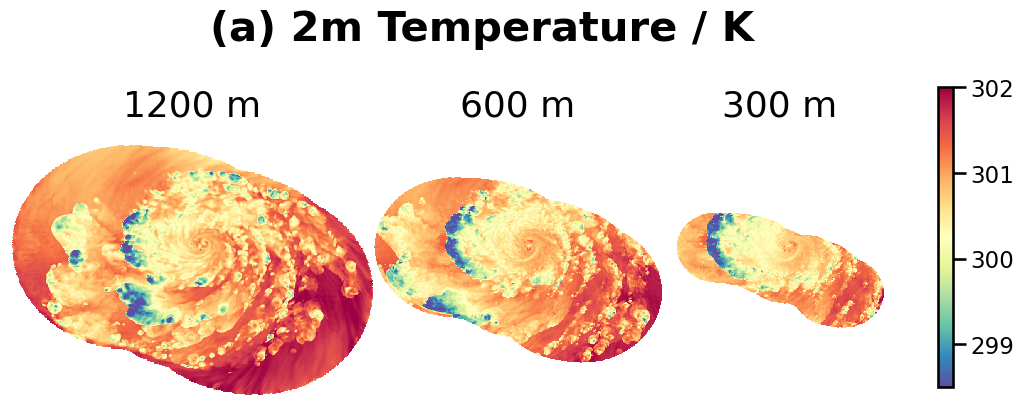

In [12]:
vname = 't_2m'
add_kws = dict( vmin = 298.5, vmax = 302, cmap = 'Spectral_r' )
title = '(a) 2m Temperature / K'

general_overview_plot(d, vname, title, add_kws, xlim, ylim)

plt.savefig(f'../pics/segment_overview_{vname}_{time_str}.png', dpi=150)

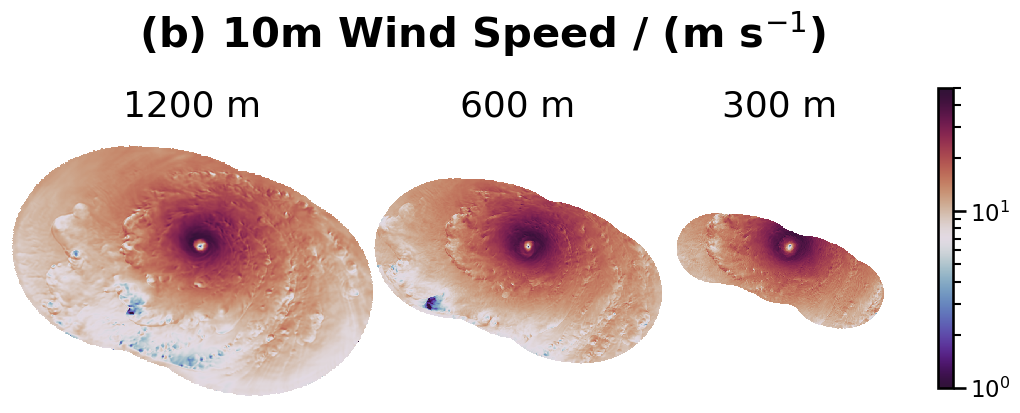

In [13]:
vname = 'speed'
mima=dict( vmin = 1, vmax = 50 )
add_kws = dict( cmap = plt.cm.twilight_shifted, norm = plt.matplotlib.colors.LogNorm(**mima), **mima )
title = r'(b) 10m Wind Speed / (m s${}^{-1}$)'

general_overview_plot(d, vname, title, add_kws, xlim, ylim)

plt.savefig(f'../pics/segment_overview_{vname}_{time_str}.png', dpi=150)

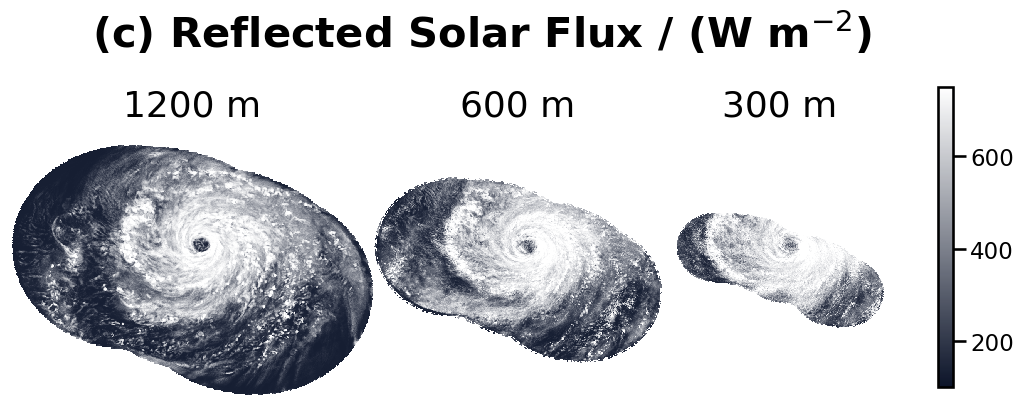

In [14]:
# Create the colormap
colors = ['#0c1429', 'white']
n_bins = 256  # Number of discrete colors in the colormap
cmap = mcolors.LinearSegmentedColormap.from_list('white_to_dark', colors, N=n_bins)

vname = 'sou_t'
add_kws = dict( vmin = 100, vmax = 750, cmap = cmap )
title = '(c) Reflected Solar Flux / (W m${}^{-2}$)'

general_overview_plot(d, vname, title, add_kws, xlim, ylim)

plt.savefig(f'../pics/segment_overview_{vname}_{time_str}.png', dpi=150)

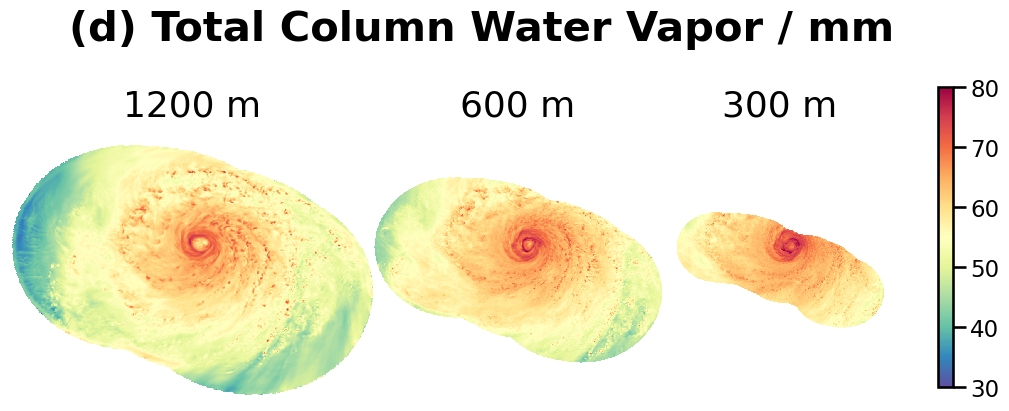

In [15]:
vname = 'tqv_dia'
add_kws = dict( vmin = 30, vmax = 80., cmap = 'Spectral_r' )
title = '(d) Total Column Water Vapor / mm'

general_overview_plot(d, vname, title, add_kws, xlim, ylim)

plt.savefig(f'../pics/segment_overview_{vname}_{time_str}.png', dpi=150)

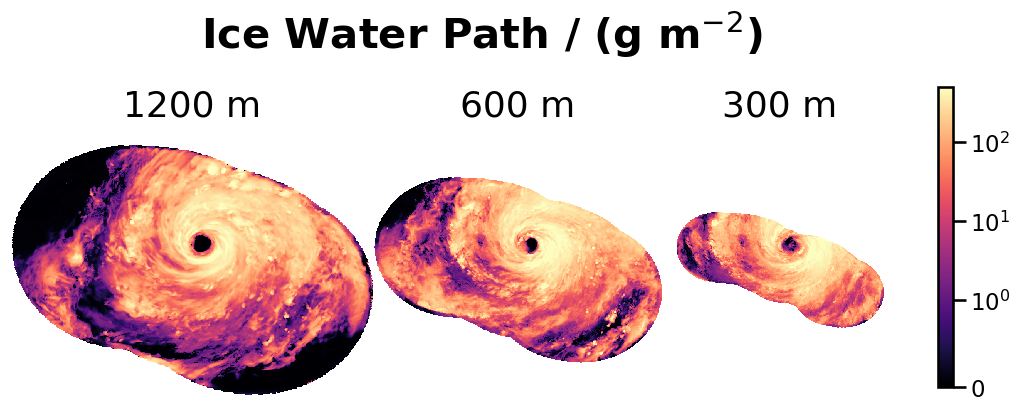

In [16]:
title = r'Ice Water Path / (g m$^{-2}$)'
vname = 'tqi_dia'
mima = dict( vmin = 0, vmax = 1e3/2.)
add_kws = dict( norm = plt.matplotlib.colors.SymLogNorm(linthresh = 1., **mima), 
              cmap = plt.cm.magma, **mima)

general_overview_plot(d, vname, title, add_kws, xlim, ylim, scale = 1e3,)

#plt.savefig(f'../pics/segment_overview_{vname}_{time_str}.png', dpi=150)